In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("heart_disease_dataset.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,62,M,ASY,182,251,1,ST,131,Y,0.9,Flat,1
1,48,F,ATA,185,276,0,LVH,139,N,5.5,Down,1
2,39,F,ASY,147,325,0,LVH,115,N,5.0,Flat,1
3,78,M,ATA,159,140,0,ST,150,Y,0.6,Flat,1
4,62,M,ATA,185,190,1,Normal,83,Y,4.7,Up,1


# EDA

In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [5]:
df.shape


(802, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 802 entries, 0 to 801
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             802 non-null    int64  
 1   Sex             802 non-null    str    
 2   ChestPainType   802 non-null    str    
 3   RestingBP       802 non-null    int64  
 4   Cholesterol     802 non-null    int64  
 5   FastingBS       802 non-null    int64  
 6   RestingECG      802 non-null    str    
 7   MaxHR           802 non-null    int64  
 8   ExerciseAngina  802 non-null    str    
 9   Oldpeak         802 non-null    float64
 10  ST_Slope        802 non-null    str    
 11  HeartDisease    802 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 75.3 KB


In [7]:
# only Numeric Data are display 
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000
mean,54.201995,140.309227,266.073566,0.491272,128.920200,3.130923,0.880299
std,14.960592,29.403247,88.448936,0.500236,41.998022,1.778858,0.324814
min,28.000000,90.000000,0.000000,0.000000,60.000000,0.000000,0.000000
25%,42.000000,116.000000,191.000000,0.000000,92.000000,1.700000,1.000000
50%,54.000000,141.000000,270.000000,0.000000,128.000000,3.100000,1.000000
75%,67.000000,164.750000,341.750000,1.000000,165.000000,4.675000,1.000000
max,80.000000,190.000000,420.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['HeartDisease'].value_counts()

HeartDisease
1    706
0     96
Name: count, dtype: int64

<Axes: xlabel='HeartDisease'>

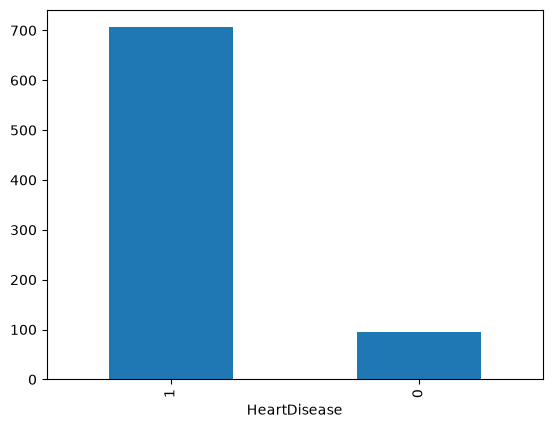

In [10]:
df['HeartDisease'].value_counts().plot(kind = "bar")

In [11]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

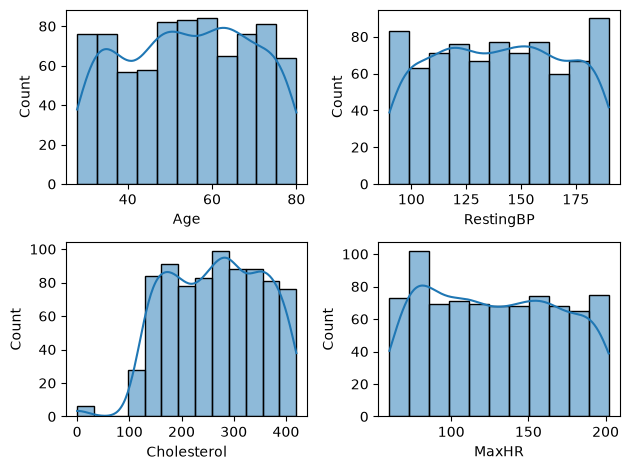

In [12]:
def plotting (var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
#if image space collaps each other then remove by using this:
plt.tight_layout()

In [22]:
#if this not show full data then use Case1 in below code:
df['Cholesterol'].value_counts()

Cholesterol
350    8
173    8
174    7
192    7
151    7
139    7
281    7
393    7
276    6
0      6
189    6
238    6
268    6
182    6
142    6
399    6
168    6
222    6
251    5
288    5
302    5
196    5
314    5
132    5
387    5
145    5
339    5
198    5
147    5
335    5
165    5
370    5
307    5
294    5
354    5
186    5
246    5
410    5
363    5
241    5
284    5
286    5
217    4
401    4
293    4
365    4
274    4
300    4
340    4
195    4
289    4
371    4
375    4
279    4
347    4
287    4
359    4
124    4
125    4
249    4
299    4
263    4
353    4
277    4
171    4
292    4
346    4
253    4
170    4
127    4
320    4
141    4
368    4
215    4
361    4
123    4
341    4
213    4
175    4
260    4
199    4
252    3
329    3
388    3
416    3
331    3
265    3
336    3
250    3
315    3
344    3
304    3
227    3
184    3
348    3
210    3
323    3
355    3
266    3
404    3
129    3
176    3
235    3
157    3
385    3
384    3
256    3
167    3
413    3
248    

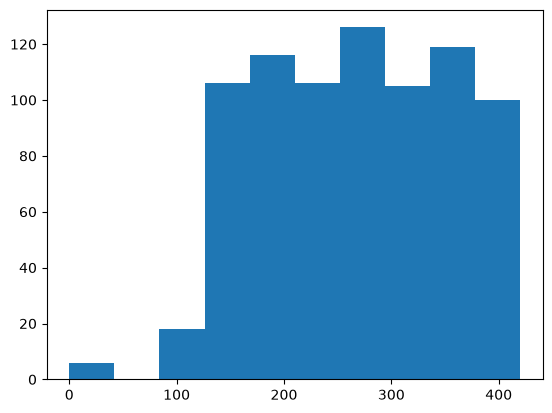

In [21]:
import matplotlib.pyplot as plt

plt.hist(df['Cholesterol'])
plt.show()

In [23]:
# Case1 
# pd.set_option('display.max_rows', None)
# print(df['Cholesterol'].value_counts().sort_index())

In [28]:
#fill 0 value with mean value
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
print(ch_mean)

268.0791457286432


In [31]:
#this code replace Zero value with mean value 
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

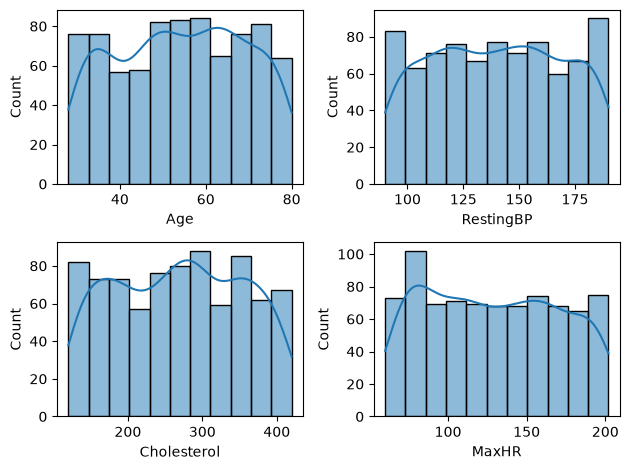

In [32]:
def plotting (var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
#if image space collaps each other then remove by using this:
plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

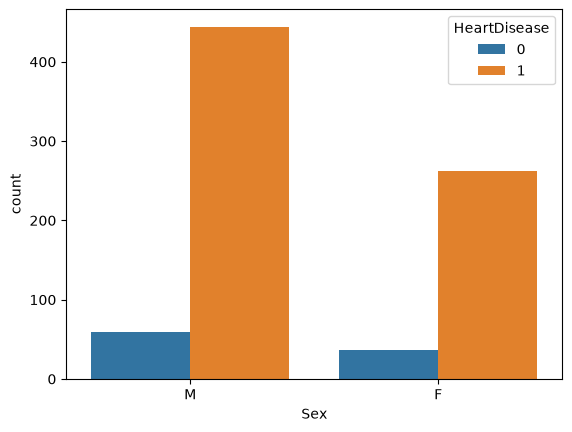

In [36]:
sns.countplot(x= df['Sex'],hue = df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

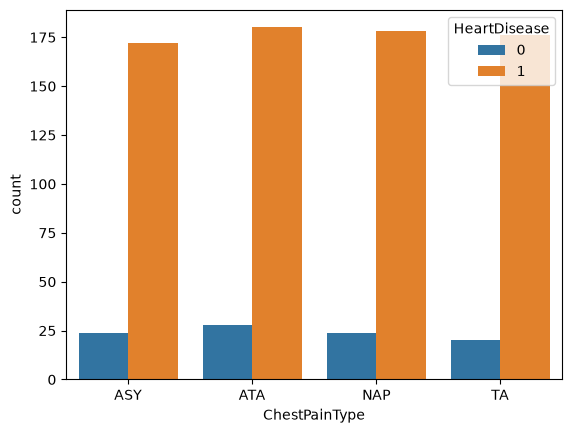

In [35]:
sns.countplot(x = df['ChestPainType'],hue = df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

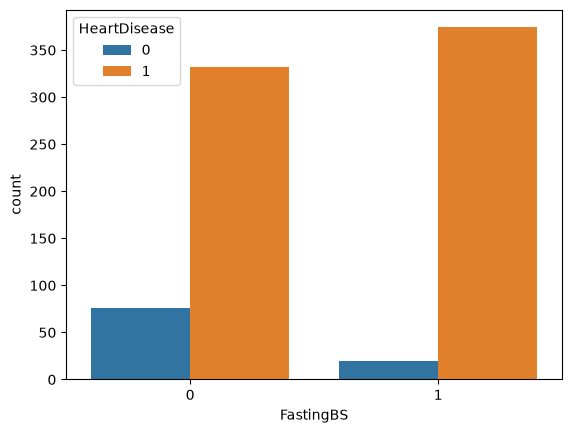

In [37]:
sns.countplot(x = df['FastingBS'],hue = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

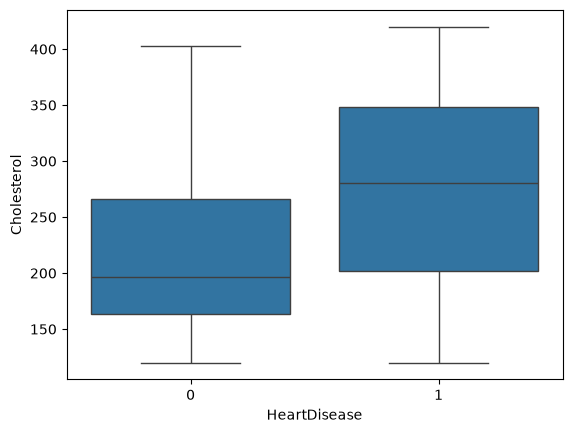

In [40]:
sns.boxplot( x = 'HeartDisease',y ='Cholesterol' ,data =df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

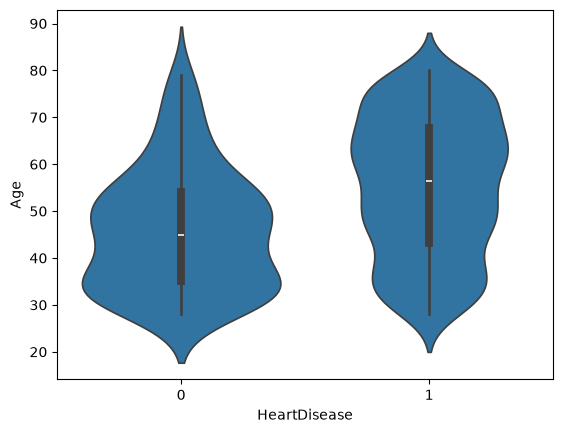

In [41]:
# this show that if a person 50-80 then high chance of HeartDisease acc to fig(1)
sns.violinplot( x = 'HeartDisease',y ='Age' ,data =df)

<Axes: >

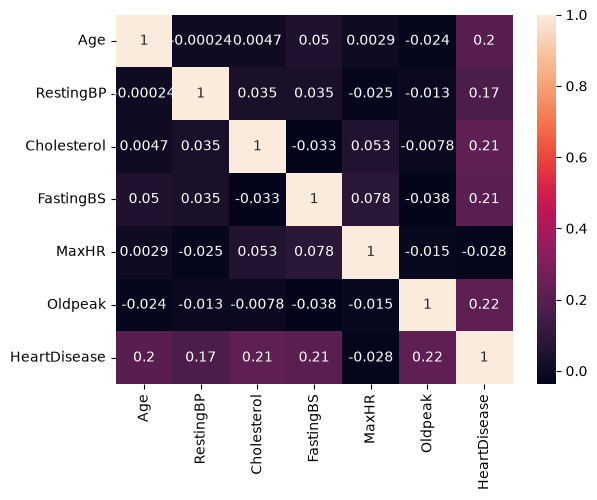

In [43]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

# Data Processing and cleaning

In [44]:
df_encode = pd.get_dummies(df,drop_first = True)

In [45]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,62,182,251.00,1,131,0.9,1,True,False,False,False,False,True,True,True,False
1,48,185,276.00,0,139,5.5,1,False,True,False,False,False,False,False,False,False
2,39,147,325.00,0,115,5.0,1,False,False,False,False,False,False,False,True,False
3,78,159,140.00,0,150,0.6,1,True,True,False,False,False,True,True,True,False
4,62,185,190.00,1,83,4.7,1,True,True,False,False,True,False,True,False,True
5,48,162,268.08,1,173,5.2,1,False,False,False,False,False,True,True,False,True
6,55,171,288.00,0,171,1.1,0,True,False,True,False,False,False,False,False,True
7,28,102,201.00,0,196,3.4,0,True,True,False,False,True,False,False,True,False
8,73,119,217.00,0,163,4.3,1,True,False,False,True,False,True,False,False,False
9,60,103,302.00,0,98,4.6,1,True,False,False,False,False,False,True,False,True


In [46]:
df_encode = df_encode.astype(int)

In [49]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,62,182,251,1,131,0,1,1,0,0,0,0,1,1,1,0
1,48,185,276,0,139,5,1,0,1,0,0,0,0,0,0,0
2,39,147,325,0,115,5,1,0,0,0,0,0,0,0,1,0
3,78,159,140,0,150,0,1,1,1,0,0,0,1,1,1,0
4,62,185,190,1,83,4,1,1,1,0,0,1,0,1,0,1
5,48,162,268,1,173,5,1,0,0,0,0,0,1,1,0,1
6,55,171,288,0,171,1,0,1,0,1,0,0,0,0,0,1
7,28,102,201,0,196,3,0,1,1,0,0,1,0,0,1,0
8,73,119,217,0,163,4,1,1,0,0,1,0,1,0,0,0
9,60,103,302,0,98,4,1,1,0,0,0,0,0,1,0,1


In [50]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,0.521562,1.418782,-0.200166,1,0.049552,-1.517794,1,1,0,0,0,0,1,1,1,0
1,-0.414814,1.520875,0.092842,0,0.240156,1.301268,1,0,1,0,0,0,0,0,0,0
2,-1.016770,0.227694,0.667138,0,-0.331656,1.301268,1,0,0,0,0,0,0,0,1,0
3,1.591705,0.636067,-1.501122,0,0.502237,-1.517794,1,1,1,0,0,0,1,1,1,0
4,0.521562,1.520875,-0.915106,1,-1.094072,0.737455,1,1,1,0,0,1,0,1,0,1
